In [1]:
# подключение библиотек

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import sys
sys.path.append('custom_modules')

import Data_processing as dp

from IPython.display import display
from matplotlib import ticker
from pathlib import Path
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Reshape, Input, Dense, Flatten, Conv2D, Dropout, Conv2DTranspose
from tensorflow.keras.layers import MaxPooling2D, UpSampling2D, concatenate, BatchNormalization

In [2]:
# Пути к обработанным данным
# Пути к X части выборки с массивами в каждой ячейке
path_to_array_like_X_data = 'data/Prepared data/Run1/X_data_array_like.xlsx'
# Пути к Y части выборки
path_to_Y_data = 'data/Prepared data/Run1/Y_data(binary_classification).xlsx'


In [3]:
# размер кропа
PREP_image_size = 32
# шаг кропа
PREP_crop_step = 3

In [4]:
# детерминация случайных величин, отвечающих за выбор первоначальных весов и биасов
tf.compat.v1.set_random_seed(290)
tf.random.set_seed(290)

In [5]:
# расширить датафрейм, добавив справа 63 первых столбца
# и снизу 63 первых строки
def extend_df_for_prediction(df, crop_size, crop_step):

    print('||||||||||||||||||')
    print('Df extending for better prediction')
    print('Original df size: ', df.shape)
    print('Crop windows height/width: ', crop_size)
    print('Crop windows step across rows and cols: ', crop_step)

    extend_dims = crop_size - 1
    
    df = pd.concat([df,df.iloc[:,:extend_dims]],axis=1,ignore_index=True)
    df = pd.concat([df,df.iloc[:extend_dims,:]],axis=0,ignore_index=True)
        
    print('New df shape: ', df.shape)
    print('||||||||||||||||||\n')

    dp.reshape_df_for_future_crops(df,crop_size,crop_step)
    
    return df

In [6]:
# загрузка данных из файлов
X_dict = dict()
Y_dict = dict()

X_dict['df'] =  dp.get_array_like_X_df(path_to_array_like_X_data)
Y_dict['df'] =  dp.get_Y_df(path_to_Y_data)

#X_dict['df'] = pd.concat([X_dict['df'].iloc[:,200:],X_dict['df'].iloc[:,:200]],axis=1,ignore_index=True)
#Y_dict['df'] = pd.concat([Y_dict['df'].iloc[:,200:],Y_dict['df'].iloc[:,:200]],axis=1,ignore_index=True)

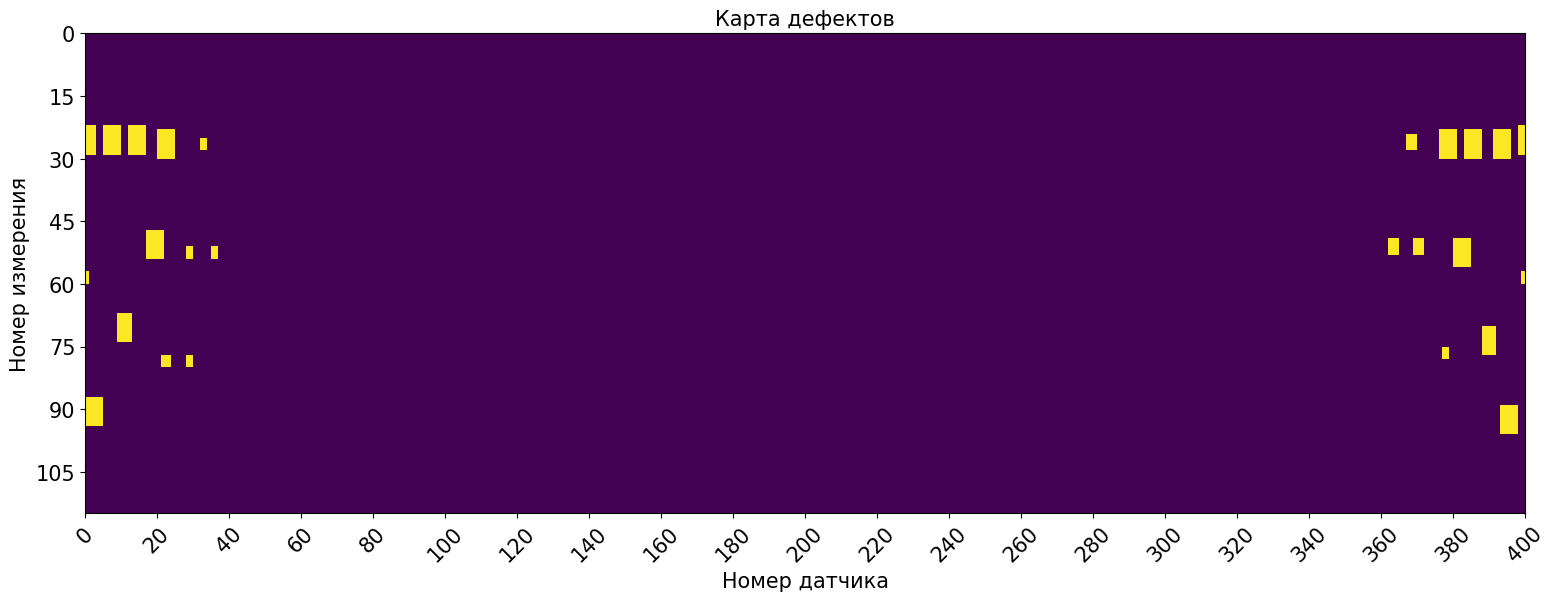

In [7]:
fig, axes = plt.subplots()

fig.set_figwidth(18)
fig.set_figheight(6)

axes.pcolormesh(Y_dict['df'])
axes.invert_yaxis()

axes.set_xlabel('Номер датчика', fontsize=15) 
axes.set_ylabel('Номер измерения', fontsize=15) 
axes.set_title(f'Карта дефектов', fontsize=15) 

#  Устанавливаем интервал основных делений: 
axes.xaxis.set_major_locator(ticker.MultipleLocator(20)) 
axes.yaxis.set_major_locator(ticker.MultipleLocator(15)) 
 
#  Устанавливаем форматирование чисел основных делений: 
axes.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.d')) 
axes.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.d')) 
 
#  Устанавливаем форматирование делений: 
axes.xaxis.set_tick_params(which = 'major', labelsize = 15, labelrotation = 45) 
axes.yaxis.set_tick_params(which = 'major', labelsize = 15) 
     
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.1, hspace=0.2)
plt.show()

In [8]:
# Добавление строк в датафреймы
# Справа к каждому датафрейму дописывается по 63
# элемента, чтобы сымитировать сканирование 
# трубы по всей окружности фильтром размера 64 на 64
# а еще дописывается некоторое количество строк и столбцов
# меньшее чем шаг кропа. Чтобы датафрейм можно было поделить
# на целое кол-во кропов

print('||||||||||| X df preprocessing |||||||||||')
#X_dict['df'] = dp.reshape_df_for_future_crops(X_dict['df'], PREP_image_size, PREP_crop_step)
X_dict['df'] = extend_df_for_prediction(X_dict['df'], PREP_image_size, PREP_crop_step)

print('||||||||||| Y df preprocessing |||||||||||')
#Y_dict['df'] = dp.reshape_df_for_future_crops(Y_dict['df'], PREP_image_size, PREP_crop_step)
Y_dict['df'] = extend_df_for_prediction(Y_dict['df'], PREP_image_size, PREP_crop_step)

||||||||||| X df preprocessing |||||||||||
||||||||||||||||||
Df extending for better prediction
Original df size:  (115, 400)
Crop windows height/width:  32
Crop windows step across rows and cols:  3
New df shape:  (146, 431)
||||||||||||||||||

||||||||||||||||||
Df reshaping for exact splitting with crop_size
Original df size:  (146, 431)
Crop windows height/width:  32
Crop windows step across rows and cols:  3
New df shape:  (146, 431)
||||||||||||||||||

||||||||||| Y df preprocessing |||||||||||
||||||||||||||||||
Df extending for better prediction
Original df size:  (115, 400)
Crop windows height/width:  32
Crop windows step across rows and cols:  3
New df shape:  (146, 431)
||||||||||||||||||

||||||||||||||||||
Df reshaping for exact splitting with crop_size
Original df size:  (146, 431)
Crop windows height/width:  32
Crop windows step across rows and cols:  3
New df shape:  (146, 431)
||||||||||||||||||



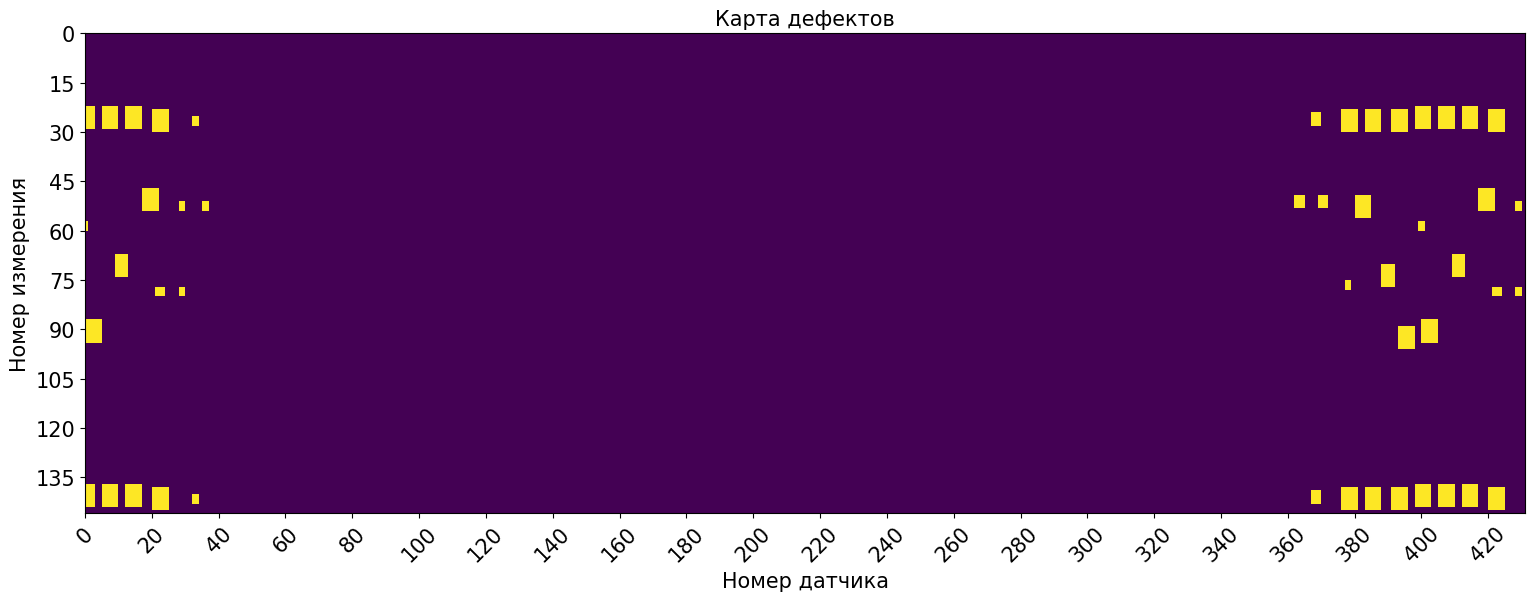

In [9]:
fig, axes = plt.subplots()

fig.set_figwidth(18)
fig.set_figheight(6)

axes.pcolormesh(Y_dict['df'])
axes.invert_yaxis()

axes.set_xlabel('Номер датчика', fontsize=15) 
axes.set_ylabel('Номер измерения', fontsize=15) 
axes.set_title(f'Карта дефектов', fontsize=15) 

#  Устанавливаем интервал основных делений: 
axes.xaxis.set_major_locator(ticker.MultipleLocator(20)) 
axes.yaxis.set_major_locator(ticker.MultipleLocator(15)) 
 
#  Устанавливаем форматирование чисел основных делений: 
axes.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.d')) 
axes.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.d')) 
 
#  Устанавливаем форматирование делений: 
axes.xaxis.set_tick_params(which = 'major', labelsize = 15, labelrotation = 45) 
axes.yaxis.set_tick_params(which = 'major', labelsize = 15) 

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.1, hspace=0.2)
plt.show()

In [10]:
# запишем в словарь numpy array полученные из df

print('||||||||||| X df preprocessing |||||||||||')
x_time_temp, \
x_amp_temp = dp.reshape_X_df_to_image_like_numpy(X_dict['df'], 
                                                    PREP_image_size, 
                                                    PREP_crop_step)
X_dict['X_time_all'] = x_time_temp.astype('float32')
X_dict['X_amp_all'] = x_amp_temp.astype('float32')

X_dict.pop('df',0)

print('||||||||||| Y df preprocessing |||||||||||')
y_temp = dp.reshape_Y_df_to_image_like_numpy(Y_dict['df'], 
                                             PREP_image_size, 
                                             PREP_crop_step)
Y_dict['Y_mask_all'] = y_temp.astype('int8')

Y_dict.pop('df',0)

print('\n')

||||||||||| X df preprocessing |||||||||||
||||||||||||||||||
X df reshaping to 4D
Original df size:  (146, 431)
Crop windows height/width:  32
Crop windows step across rows and cols:  3
New X_time shape:  (5226, 32, 32, 32)
New X_amp shape:  (5226, 32, 32, 32)
||||||||||||||||||

||||||||||| Y df preprocessing |||||||||||
||||||||||||||||||
Y df reshaping to 3D
Original df size:  (146, 431)
Crop windows height/width:  32
Crop windows step across rows and cols:  3
New numpy shape:  (5226, 32, 32, 1)
||||||||||||||||||





In [11]:
# что есть на данный момент

print('|||||||||||||| X dataset ||||||||||||||||')
for key in X_dict.keys():
    print(f"{key}.shape: ", X_dict[key].shape)

print('\n|||||||||||||| Y dataset ||||||||||||||||')
for key in Y_dict.keys():
    print(f"{key}.shape: ", Y_dict[key].shape)

|||||||||||||| X dataset ||||||||||||||||
X_time_all.shape:  (5226, 32, 32, 32)
X_amp_all.shape:  (5226, 32, 32, 32)

|||||||||||||| Y dataset ||||||||||||||||
Y_mask_all.shape:  (5226, 32, 32, 1)


In [12]:
# нормализация данных

print('|||||||||||||| X dataset ||||||||||||||||')
for key in X_dict.keys():
    print(f"|||||||||||||| dataset part: {key}||||||||||||||||")
    X_dict[key] = dp.normalize_data(X_dict[key])

|||||||||||||| X dataset ||||||||||||||||
|||||||||||||| dataset part: X_time_all||||||||||||||||
||||||||||||||||||
Data normalizing
arr_max before normalization: 44.5
arr_max after normalization: 1.0
arr_min after normalization: 0.0
||||||||||||||||||
|||||||||||||| dataset part: X_amp_all||||||||||||||||
||||||||||||||||||
Data normalizing
arr_max before normalization: 62.992000579833984
arr_max after normalization: 1.0
arr_min after normalization: -0.9837439060211182
||||||||||||||||||


In [13]:
# деление данных на дефектные и нет

(X_time_def, X_time_non_def), \
(X_amp_def, X_amp_non_def), \
(Y_mask_def, Y_mask_non_def) = dp.split_def_and_non_def_data(X_dict['X_time_all'], 
                                                                X_dict['X_amp_all'], 
                                                                Y_dict['Y_mask_all'],
                                                                PREP_image_size)
X_dict.pop('X_time_all',0)
X_dict.pop('X_amp_all',0)
Y_dict.pop('Y_mask_all',0)
print()

X_dict['X_time_def'] = X_time_def
X_dict['X_time_non_def'] = X_time_non_def

X_dict['X_amp_def'] = X_amp_def
X_dict['X_amp_non_def'] = X_amp_non_def

Y_dict['Y_mask_def'] = Y_mask_def
Y_dict['Y_mask_non_def'] = Y_mask_non_def

||||||||||||||||||
Defect and non defect data splitting
Orig X_time shape:  (5226, 32, 32, 32)
Orig X_amp shape:  (5226, 32, 32, 32)
Orig Y_mask shape:  (5226, 32, 32, 1)
||||||||||||||||||
Defects nums calculating
Для карт высотой и шириной в 32
и общим кличеством: 5226
дефекты присутствуеют на 1056 картах
||||||||||||||||||

X_time_def shape:  (1056, 32, 32, 32)
X_time_non_def shape:  (4170, 32, 32, 32)

X_amp_def shape:  (1056, 32, 32, 32)
X_amp_non_def shape:  (4170, 32, 32, 32)

Y_mask_def shape:  (1056, 32, 32, 1)
Y_mask_non_def shape:  (4170, 32, 32, 1)

||||||||||||||||||




In [14]:
# аугментация данных

print('|||||||||||||| X dataset ||||||||||||||||')

print(f"|||||||||||||| dataset part: X_time_def||||||||||||||||")
X_dict['X_time_def'] = dp.augment_data(X_dict['X_time_def']) 

print(f"|||||||||||||| dataset part: X_amp_def||||||||||||||||")
X_dict['X_amp_def'] = dp.augment_data(X_dict['X_amp_def']) 

print('|||||||||||||| Y dataset ||||||||||||||||')

print(f"|||||||||||||| dataset part: Y_mask_def||||||||||||||||")
Y_dict['Y_mask_def'] = dp.augment_data(Y_dict['Y_mask_def']) 

|||||||||||||| X dataset ||||||||||||||||
|||||||||||||| dataset part: X_time_def||||||||||||||||
||||||||||||||||||
Data augmentation
Orig arr shape:  (1056, 32, 32, 32)
||||||||||||
After 4 steps of 90 degree rotate
arr shape:  (4224, 32, 32, 32)
||||||||||||
After horizontal full mirroring
arr shape:  (8448, 32, 32, 32)
||||||||||||
After vertical full mirroring
arr shape:  (16896, 32, 32, 32)
||||||||||||||||||

|||||||||||||| dataset part: X_amp_def||||||||||||||||
||||||||||||||||||
Data augmentation
Orig arr shape:  (1056, 32, 32, 32)
||||||||||||
After 4 steps of 90 degree rotate
arr shape:  (4224, 32, 32, 32)
||||||||||||
After horizontal full mirroring
arr shape:  (8448, 32, 32, 32)
||||||||||||
After vertical full mirroring
arr shape:  (16896, 32, 32, 32)
||||||||||||||||||

|||||||||||||| Y dataset ||||||||||||||||
|||||||||||||| dataset part: Y_mask_def||||||||||||||||
||||||||||||||||||
Data augmentation
Orig arr shape:  (1056, 32, 32, 1)
||||||||||||
After 4 steps of 90 

In [15]:
# создание выходных данных бинарного вида (одномерный массив типа bool)
Y_dict['Y_binary_def'] = dp.create_binary_arr_from_mask_arr(Y_dict['Y_mask_def'])
Y_dict['Y_binary_non_def'] = dp.create_binary_arr_from_mask_arr(Y_dict['Y_mask_non_def'])

||||||||||||||||||
Y binary arr from Y mask arr creation
Y mask arr shape:  (16896, 32, 32, 1)
Y binary arr shape:  (16896,)
||||||||||||||||||

||||||||||||||||||
Y binary arr from Y mask arr creation
Y mask arr shape:  (4170, 32, 32, 1)
Y binary arr shape:  (4170,)
||||||||||||||||||



In [16]:
# удаление лишнего
Y_dict.pop('Y_mask_def',0)
Y_dict.pop('Y_mask_non_def',0)
print()

In [17]:
# что есть на данный момент

print('|||||||||||||| X dataset ||||||||||||||||')
for key in X_dict.keys():
    print(f"{key}.shape: ", X_dict[key].shape)

print('\n|||||||||||||| Y dataset ||||||||||||||||')
for key in Y_dict.keys():
    print(f"{key}.shape: ", Y_dict[key].shape)

|||||||||||||| X dataset ||||||||||||||||
X_time_def.shape:  (16896, 32, 32, 32)
X_time_non_def.shape:  (4170, 32, 32, 32)
X_amp_def.shape:  (16896, 32, 32, 32)
X_amp_non_def.shape:  (4170, 32, 32, 32)

|||||||||||||| Y dataset ||||||||||||||||
Y_binary_def.shape:  (16896,)
Y_binary_non_def.shape:  (4170,)


In [18]:
# деление на тренировочную и валидационную выборки

val_data_percent = 0.2

X_time_train, X_time_val = dp.split_data_to_train_val_datasets([X_dict['X_time_def'],
                                                                X_dict['X_time_non_def']],
                                                                val_data_percent)
        
X_dict.pop('X_time_def',0)
X_dict.pop('X_time_non_def',0)


X_amp_train, X_amp_val = dp.split_data_to_train_val_datasets([X_dict['X_amp_def'],
                                                              X_dict['X_amp_non_def']],
                                                              val_data_percent)

X_dict.pop('X_amp_def',0)
X_dict.pop('X_amp_non_def',0)


Y_binary_train, Y_binary_val = dp.split_data_to_train_val_datasets([Y_dict['Y_binary_def'],
                                                                Y_dict['Y_binary_non_def']],
                                                                    val_data_percent)

Y_dict.pop('Y_binary_def',0)
Y_dict.pop('Y_binary_non_def',0)

print()

||||||||||||||||||
Data spliting to test, val and train datasets
Orig item shape:  (16896, 32, 32, 32)
Orig item shape:  (4170, 32, 32, 32)

Result arr_train shape:  (16853, 32, 32, 32)
Result arr_val shape:  (4213, 32, 32, 32)

||||||||||||||||||

||||||||||||||||||
Data spliting to test, val and train datasets
Orig item shape:  (16896, 32, 32, 32)
Orig item shape:  (4170, 32, 32, 32)

Result arr_train shape:  (16853, 32, 32, 32)
Result arr_val shape:  (4213, 32, 32, 32)

||||||||||||||||||

||||||||||||||||||
Data spliting to test, val and train datasets
Orig item shape:  (16896,)
Orig item shape:  (4170,)

Result arr_train shape:  (16853,)
Result arr_val shape:  (4213,)

||||||||||||||||||




In [19]:
# очистка памяти от лишнего   

X_dict.clear()
Y_dict.clear()

In [20]:
# перемешивание данных

train_shuffled_indices = np.random.permutation(X_time_train.shape[0])
val_shuffled_indices = np.random.permutation(X_time_val.shape[0])

X_time_train = X_time_train[train_shuffled_indices]
X_amp_train = X_amp_train[train_shuffled_indices]
Y_binary_train = Y_binary_train[train_shuffled_indices]

X_time_val = X_time_val[val_shuffled_indices]
X_amp_val = X_amp_val[val_shuffled_indices]
Y_binary_val = Y_binary_val[val_shuffled_indices]

In [21]:
# что есть на данный момент

print('X_time_train.shape: ', X_time_train.shape)
print('X_amp_train.shape: ', X_amp_train.shape)
print('Y_binary_train.shape', Y_binary_train.shape)
print('\n')

print('X_time_val.shape: ', X_time_val.shape)
print('X_amp_val.shape: ', X_amp_val.shape)
print('Y_binary_val.shape', Y_binary_val.shape)
print('\n')

X_time_train.shape:  (16853, 32, 32, 32)
X_amp_train.shape:  (16853, 32, 32, 32)
Y_binary_train.shape (16853,)


X_time_val.shape:  (4213, 32, 32, 32)
X_amp_val.shape:  (4213, 32, 32, 32)
Y_binary_val.shape (4213,)




In [22]:
# всякие константы для последующей работы

#///////////////////////////////// для компиляции 

CMP_learning_rate = 0.000004 #0.04 # шаг сходимости back propogation
CMP_solver = keras.optimizers.Adam(CMP_learning_rate) # оптимизатор
#CMP_solver = keras.optimizers.SGD(CMP_learning_rate) # оптимизатор
CMP_loss_func = 'mean_squared_error'# функция потерь
#///////////////////////////////// для колбэков

    # для Early_stopping
#ES_patience = 15 # кол-во эпох без улучшений
#ES_min_delta = 0.0005 # минимальное улучшение параметра за cur_patience
#ES_monitor_parametr =  'loss' # отслеживаемый параметр 
#ES_save_best_weights = False # сохранять ли веса нейронки с лучшими результатами
    
    # для ReduceLROnPlateau
#RLPOP_monitor_parametr = 'loss'  # отслеживаемый параметр 
#RLPOP_factor = 0.4 # множитель для расчета нового шага сходимости (new_learning_rate = old_learning_rate*RLPOP_factor)
#RLPOP_patience = 10 # кол-во эпох без улучшений
#RLPOP_verbose = 1 # выводить ли прогресс изменения шага сходимости в его процессее
#RLPOP_mode = 'auto' # выбирает, уменьшать шаг сходимости при росте величины или при её уменьшении
#RLPOP_min_delta = 0.001 # порог изменения отслеживаемого значения
#RLPOP_cooldown = 0 # количество эпох до возобновления работы после изменения шага сходимости
#RLPOP_min_lr = 0 # минимальное значение шага сходимости

    # для CallbackList
CBL_add_history = True # вызывать ли колбэк History (если он не был довавлен вручную)
CBL_add_progbar = True # вызывать ли колбэк ProgbarLogger (если он не был довавлен вручную)
    
#///////////////////////////////// для тренировки

FIT_batch_size = 32 # размер bach при обучении/тестировании1
FIT_shuffle = True # перемешивать ли данные
FIT_verbose = True # выводить ли прогресс обучения в его процессее
FIT_epochs = 2 # количество эпох обучения
#FIT_validation_split = 0.10 #0.20 # процент валидационных данных, отсекаемых из тестовой выборки

In [23]:
# создание архитектуры модели

# 1 подсеть //////////////////////////////////////////////////
drop_percent = 0

new_input_time = Input((32,32,32), name = 'new_input_time')
input_time = UpSampling2D(2, interpolation='bilinear', name='input_time')(new_input_time)

#48
dconv_1_1 = Conv2D(64, (5,5), dilation_rate=(4, 4), activation='relu', name='dconv_1_1')(input_time)

#24
dconv_1_2 = Conv2D(64, (5,5), dilation_rate=(10, 10), activation='relu', name='dconv_1_2')(input_time)
up_1_2 = UpSampling2D(2, interpolation='bilinear', name='up_1_2') (dconv_1_2)

#12
dconv_1_3 = Conv2D(64, (5,5), dilation_rate=(13, 13), activation='relu', name='dconv_1_3')(input_time)
up_1_3 = UpSampling2D(4, interpolation='bilinear', name='up_1_3') (dconv_1_3)

#8
dconv_1_4 = Conv2D(64, (5,5), dilation_rate=(14, 14), activation='relu', name='dconv_1_4')(input_time)
up_1_4 = UpSampling2D(6, interpolation='bilinear', name='up_1_4') (dconv_1_4)

conc_1_1 = concatenate([dconv_1_1,up_1_2,up_1_3,up_1_4],axis=3, name='conc_1_1')

conv_1_1 = Conv2D(128, (3,3), activation='relu', name='conv_1_1')(conc_1_1)
conv_1_2 = Conv2D(128, (3,3), activation='relu', name='conv_1_2')(conv_1_1)
drop_1_1 = Dropout(drop_percent, name='drop_1_1')(conv_1_2)
pool_1_1 = MaxPooling2D((2,2), strides=2, name='pool_1_1')(drop_1_1)

conv_1_3 = Conv2D(256, (3,3), activation='relu', name='conv_1_3')(pool_1_1)
conv_1_4 = Conv2D(256, (3,3), activation='relu', name='conv_1_4')(conv_1_3)
conv_1_5 = Conv2D(256, (3,3), activation='relu', name='conv_1_5')(conv_1_4)
drop_1_2 = Dropout(drop_percent, name='drop_1_2')(conv_1_5)
pool_1_2 = MaxPooling2D((2,2), strides=2, name='pool_1_2')(drop_1_2)

conv_1_6 = Conv2D(512, (3,3), activation='relu', name='conv_1_6')(pool_1_2)
conv_1_7 = Conv2D(512, (3,3), activation='relu', name='conv_1_7')(conv_1_6)
conv_1_8 = Conv2D(512, (3,3), activation='relu', name='conv_1_8')(conv_1_7)
drop_1_3 = Dropout(drop_percent, name='drop_1_3')(conv_1_8)
pool_1_3 = MaxPooling2D((2,2), strides=2, name='pool_1_3')(drop_1_3)

# 2 подсеть //////////////////////////////////////////////////

new_input_amp = Input((32,32,32), name = 'new_input_amp')
input_amp = UpSampling2D(2, interpolation='bilinear', name='input_amp')(new_input_amp)

#48
dconv_2_1 = Conv2D(64, (5,5), dilation_rate=(4, 4), activation='linear', name='dconv_2_1')(input_amp)

#24
dconv_2_2 = Conv2D(64, (5,5), dilation_rate=(10, 10), activation='linear', name='dconv_2_2')(input_amp)
up_2_2 = UpSampling2D(2, interpolation='bilinear', name='up_2_2') (dconv_2_2)

#12
dconv_2_3 = Conv2D(64, (5,5), dilation_rate=(13, 13), activation='linear', name='dconv_2_3')(input_amp)
up_2_3 = UpSampling2D(4, interpolation='bilinear', name='up_2_3') (dconv_2_3)

#8
dconv_2_4 = Conv2D(64, (5,5), dilation_rate=(14, 14), activation='linear', name='dconv_2_4')(input_amp)
up_2_4 = UpSampling2D(6, interpolation='bilinear', name='up_2_4') (dconv_2_4)

conc_2_1 = concatenate([dconv_2_1,up_2_2,up_2_3,up_2_4],axis=3, name='conc_2_1')

conv_2_1 = Conv2D(128, (3,3), activation='linear', name='conv_2_1')(conc_2_1)
conv_2_2 = Conv2D(128, (3,3), activation='linear', name='conv_2_2')(conv_2_1)
drop_2_1 = Dropout(drop_percent, name='drop_2_1')(conv_2_2)
pool_2_1 = MaxPooling2D((2,2), strides=2, name='pool_2_1')(drop_2_1)

conv_2_3 = Conv2D(256, (3,3), activation='linear', name='conv_2_3')(pool_2_1)
conv_2_4 = Conv2D(256, (3,3), activation='linear', name='conv_2_4')(conv_2_3)
conv_2_5 = Conv2D(256, (3,3), activation='linear', name='conv_2_5')(conv_2_4)
drop_2_2 = Dropout(drop_percent, name='drop_2_2')(conv_2_5)
pool_2_2 = MaxPooling2D((2,2), strides=2, name='pool_2_2')(drop_2_2)

conv_2_6 = Conv2D(512, (3,3), activation='linear', name='conv_2_6')(pool_2_2)
conv_2_7 = Conv2D(512, (3,3), activation='linear', name='conv_2_7')(conv_2_6)
conv_2_8 = Conv2D(512, (3,3), activation='linear', name='conv_2_8')(conv_2_7)
drop_2_3 = Dropout(drop_percent, name='drop_2_3')(conv_2_8)
pool_2_3 = MaxPooling2D((2,2), strides=2, name='pool_2_3')(drop_2_3)

# выходная сеть //////////////////////////////////////////////////

conc_3_1 = concatenate([pool_1_3,pool_2_3],axis=3, name='conc_3_1')
flat = Flatten(name='flat')(conc_3_1)

d_1_1 = Dense(512, activation='linear', name='d_1_1')(flat)
drop_3_1 = Dropout(drop_percent, name='drop_3_1')(d_1_1)

d_1_2 = Dense(512, activation='linear', name='d_1_2')(flat)
drop_3_2 = Dropout(drop_percent, name='drop_3_2')(d_1_2)

d_1_3 = Dense(512, activation='linear', name='d_1_3')(flat)
drop_3_3 = Dropout(drop_percent, name='drop_3_3')(d_1_3)

conc_3_2 = concatenate([drop_3_1,drop_3_2],axis=1, name='conc_3_2')
conc_3_3 = concatenate([drop_3_1,drop_3_3],axis=1, name='conc_3_3')
conc_3_4 = concatenate([drop_3_2,drop_3_3],axis=1, name='conc_3_4')

d_2_1 = Dense(512, activation='linear', name='d_2_1')(conc_3_2)
drop_4_1 = Dropout(drop_percent, name='drop_4_1')(d_2_1)

d_2_2 = Dense(512, activation='linear', name='d_2_2')(conc_3_3)
drop_4_2 = Dropout(drop_percent, name='drop_4_2')(d_2_2)

d_2_3 = Dense(512, activation='linear', name='d_2_3')(conc_3_4)
drop_4_3 = Dropout(drop_percent, name='drop_4_3')(d_2_3)


conc_3_5 = concatenate([drop_4_1,drop_4_2,drop_4_3],axis=1, name='conc_3_5')

d_3_1 = Dense(1024, activation='linear', name='d_3_1')(conc_3_5)
d_3_2 = Dense(256, activation='linear', name='d_3_2')(d_3_1)
d_3_3 = Dense(64, activation='linear', name='d_3_3')(d_3_2)
d_3_4 = Dense(16, activation='linear', name='d_3_4')(d_3_3)
d_3_5 = Dense(4, activation='linear', name='d_3_5')(d_3_4)
output = Dense(1, activation='sigmoid', name='output')(d_3_5)

model = keras.Model([new_input_time, new_input_amp], 
                    output, name='model')
model.compile(optimizer=CMP_solver, 
              loss=CMP_loss_func)
print(model.summary())

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
new_input_time (InputLayer)     [(None, 32, 32, 32)] 0                                            
__________________________________________________________________________________________________
new_input_amp (InputLayer)      [(None, 32, 32, 32)] 0                                            
__________________________________________________________________________________________________
input_time (UpSampling2D)       (None, 64, 64, 32)   0           new_input_time[0][0]             
__________________________________________________________________________________________________
input_amp (UpSampling2D)        (None, 64, 64, 32)   0           new_input_amp[0][0]              
______________________________________________________________________________________________

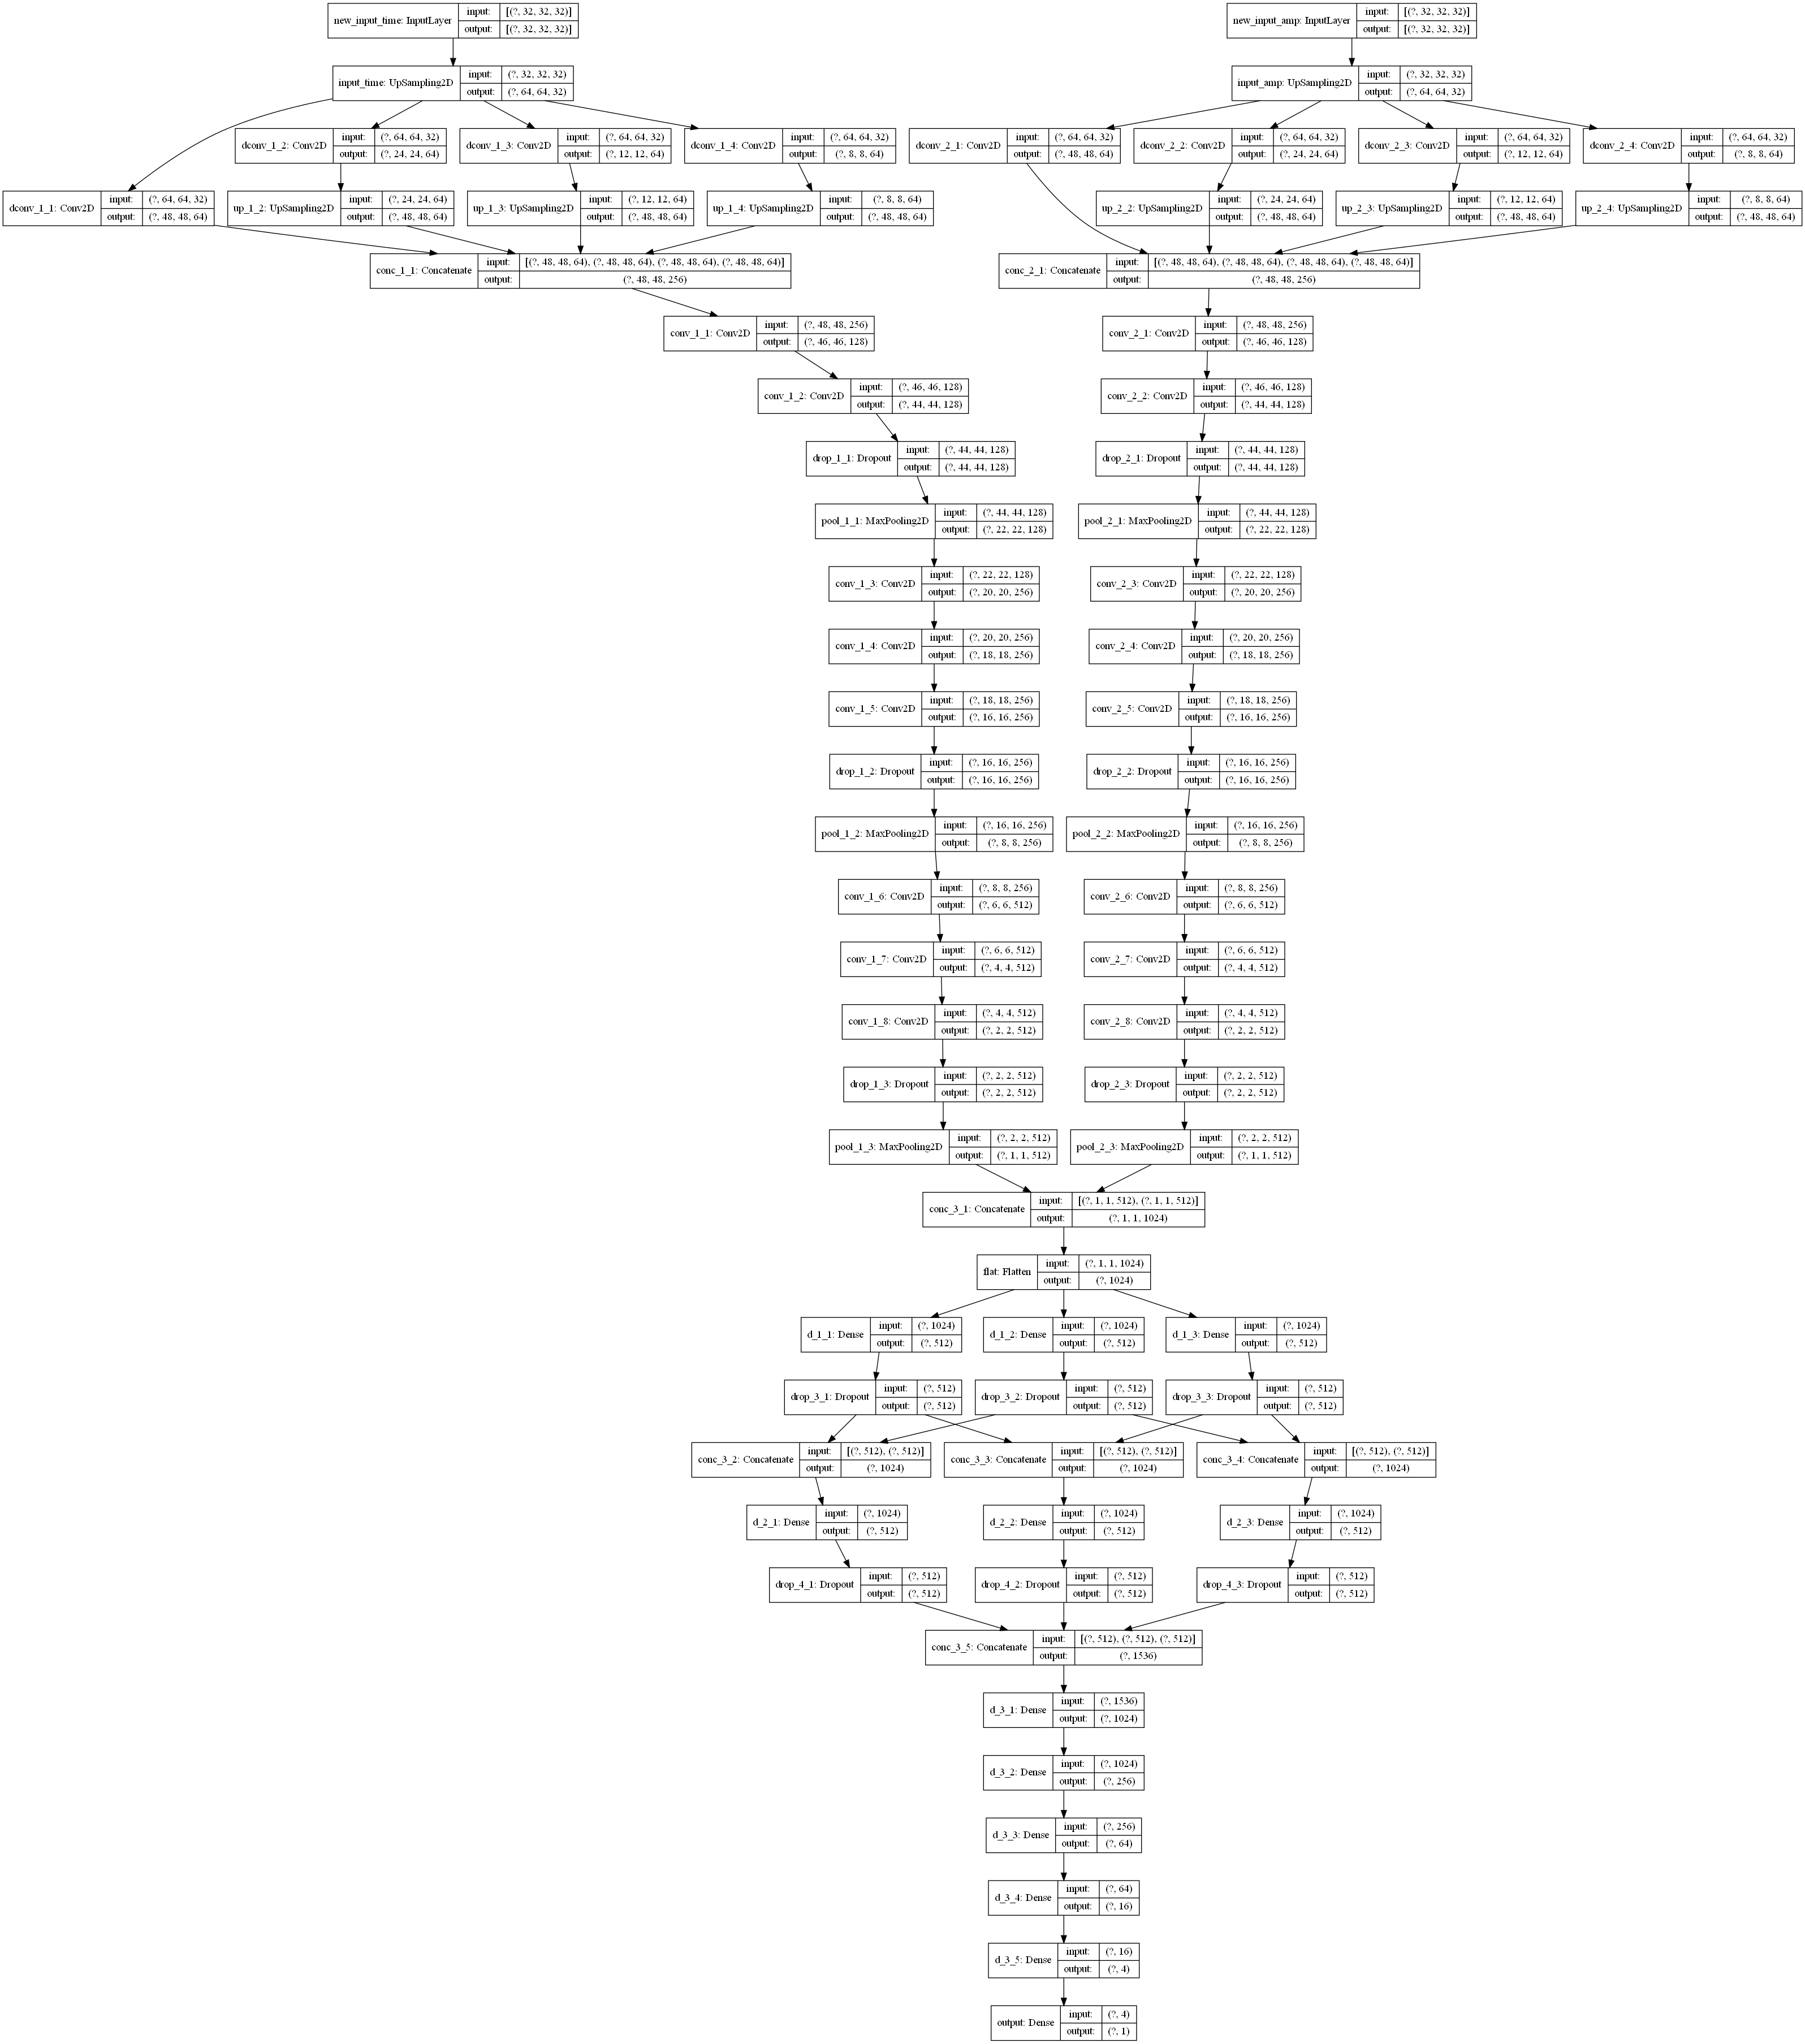

In [24]:
# как выглядит готовая модель

plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)#, show_layer_activations=True)

In [25]:
# Создание и настройка колбэков

callback_list = [] # массив колбэков до подачи в колбек "callbacklist"

'''temp = keras.callbacks.EarlyStopping(
            monitor = ES_monitor_parametr, 
            min_delta = ES_min_delta, 
            patience = ES_patience,
            restore_best_weights = ES_save_best_weights
            )
callback_list.append(temp)

temp = keras.callbacks.ReduceLROnPlateau(
            monitor = RLPOP_monitor_parametr, 
            factor = RLPOP_factor, 
            patience = RLPOP_patience, 
            verbose = RLPOP_verbose,
            mode = RLPOP_mode, 
            min_delta = RLPOP_min_delta, 
            cooldown = RLPOP_cooldown, 
            min_lr = RLPOP_min_lr
            )
callback_list.append(temp)'''

FIT_callback_list = keras.callbacks.CallbackList(
            callbacks = callback_list, 
            add_history = CBL_add_history, 
            add_progbar = CBL_add_progbar, 
            model = model
            )

In [26]:
history = model.fit([X_time_train,X_amp_train],
                    Y_binary_train,
                    batch_size = FIT_batch_size, 
                    epochs = FIT_epochs, 
                    verbose = FIT_verbose, 
                    validation_data = ([X_time_val,X_amp_val],Y_binary_val), 
                    shuffle = FIT_shuffle,
                    callbacks = FIT_callback_list)

527/527 [==============================] - 1815s 3s/step - loss: 0.0393 - val_loss: 0.1014


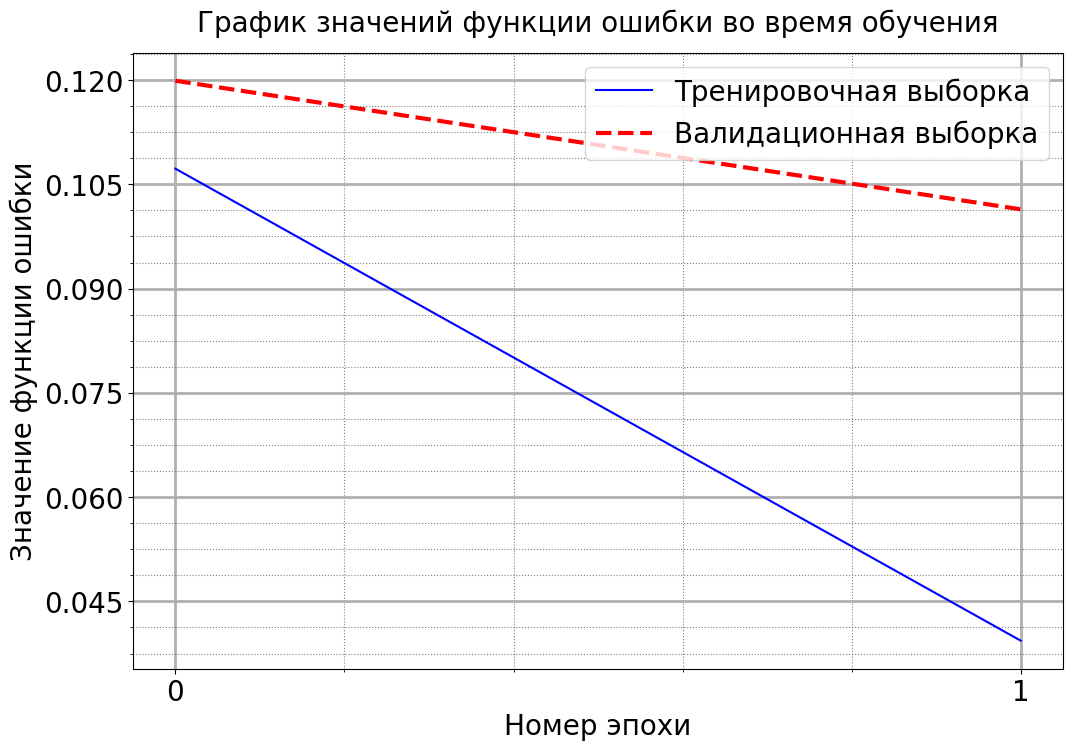

In [27]:
fig, ax = plt.subplots()

fig.set_figwidth(12)
fig.set_figheight(8)

plt.plot(history.history['loss'], 
         label='Тренировочная выборка',  linewidth=1.5, color='blue')
plt.plot(history.history['val_loss'], linestyle = '--', 
         label='Валидационная выборка',  linewidth=3, color='red')

ax.set_xlabel('Номер эпохи', fontsize=20)
ax.set_ylabel('Значение функции ошибки', fontsize=20)
ax.set_title(f"График значений функции ошибки во время обучения", fontsize=20, pad=15)

ax.patch.set_alpha(0)

#  Устанавливаем интервал основных делений:
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.015))

#  Устанавливаем форматирование чисел основных делений:
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.d'))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

#  Устанавливаем форматирование делений:
ax.tick_params(axis='both', which='both', labelsize = 20)

# Вывод и настройка сетки
ax.minorticks_on()
ax.grid(which='major', linewidth=2)
ax.grid(which='minor', color = 'gray', linestyle = ':')

ax.legend(fontsize = 20, facecolor = "white", loc = 'upper right')

plt.show()

In [28]:
# сохранение модели в файл

model.save("Networks//CNN//NetWork_(32x32+32x32)_to(1)_(test_0dot0)_ver_10.h5", save_format="h5")